# Implementación híbrida de algoritmos de optimización  
## GA + SA aplicado a mantenimiento predictivo en UCEN – Unión Cementera Nacional

**Nombre:** Jhoffre Moreano Goyes
**Asignatura:** Algoritmos bioinspirados y de trayectoria  
**Tema:** Implementación híbrida, comparación y análisis de resultados  

En este notebook se desarrolla una implementación híbrida secuencial usando un **Algoritmo Genético (GA)** y **Recocido Simulado (SA)**.  
El problema seleccionado será una función de optimización sencilla llamada **Rastrigin**, que se usa con frecuencia para probar algoritmos de optimización porque tiene varios mínimos locales.

La idea se relaciona con el mantenimiento predictivo en **UCEN – Unión Cementera Nacional**, ya que en una planta cementera se pueden optimizar variables como vibración, temperatura, presión, consumo energético, horas de operación y criticidad de equipos. Estos valores pueden ayudar a planificar mantenimientos antes de que ocurra una falla.

## 2. Implementación híbrida

Para este trabajo se utilizará un esquema híbrido **secuencial GA + SA**.

Primero se aplica el **Algoritmo Genético (GA)** para explorar varias soluciones posibles dentro del espacio de búsqueda. Luego, la mejor solución encontrada por GA se toma como punto inicial para el **Recocido Simulado (SA)**, con el fin de mejorarla localmente.

Esta combinación es útil porque el GA tiene buena capacidad de exploración global, mientras que SA ayuda a refinar la solución y escapar de mínimos locales. En el contexto del mantenimiento predictivo de UCEN, esto puede representar la búsqueda de una mejor combinación de variables para anticipar fallas y reducir paradas no planificadas.

### Justificación breve de la elección

Se eligió el esquema híbrido **GA + SA** porque permite combinar dos enfoques diferentes de optimización:

- **GA:** trabaja con una población de soluciones y permite explorar varias alternativas.
- **SA:** trabaja desde una solución inicial y realiza una búsqueda más detallada alrededor de ella.

En mantenimiento predictivo, esto es importante porque no basta con encontrar una solución aceptable; se necesita buscar una solución más eficiente que reduzca costos, tiempos de parada y riesgos de falla en equipos críticos como molinos, hornos, motores y bandas transportadoras.

In [1]:
# Importación de librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# Para que los resultados sean reproducibles en algunas partes
np.random.seed(42)

## 3. Aplicación a un problema de optimización

El problema seleccionado es la **función Rastrigin** en dos dimensiones. Esta función se utiliza para evaluar algoritmos de optimización porque tiene muchos mínimos locales y un mínimo global conocido.

El objetivo es encontrar los valores de `x` e `y` que minimicen la función.  
El mínimo global de Rastrigin está en:

**x = 0, y = 0**, con un valor mínimo de **0**.

En el caso de UCEN, esta función se puede interpretar de forma didáctica como la búsqueda de la mejor combinación de parámetros operativos de una máquina para minimizar el riesgo de falla.

In [2]:
# Definición de la función Rastrigin
def rastrigin(x):
    '''
    Función Rastrigin en n dimensiones.
    En este caso se usará principalmente con dos variables.
    El mínimo global está en x = [0, 0] y su valor es 0.
    '''
    A = 10
    x = np.array(x)
    n = len(x)
    return A * n + np.sum(x**2 - A * np.cos(2 * np.pi * x))

# Prueba rápida de la función en el punto óptimo
rastrigin([0, 0])

np.float64(0.0)

### Parámetros generales del problema

Se trabajará con dos variables dentro del intervalo de búsqueda de -5.12 a 5.12, que es el rango común usado para la función Rastrigin.

In [4]:
# Parámetros generales
DIMENSIONES = 2
LIMITE_INFERIOR = -5.12
LIMITE_SUPERIOR = 5.12

# Número de ejecuciones solicitadas
EJECUCIONES = 5

## Algoritmo 1: Algoritmo Genético (GA)

El Algoritmo Genético simula el proceso de evolución natural.  
En este caso, cada individuo representa una posible solución `[x, y]`.

El algoritmo realiza los siguientes pasos:

1. Crear una población inicial.
2. Evaluar la calidad de cada individuo.
3. Seleccionar los mejores individuos.
4. Cruzar soluciones para generar nuevos candidatos.
5. Aplicar mutación para mantener diversidad.
6. Repetir el proceso durante varias generaciones.

In [6]:
def algoritmo_genetico(generaciones=100, tam_poblacion=40, prob_mutacion=0.15):
    '''
    Implementación simple de un Algoritmo Genético para minimizar Rastrigin.
    '''
    inicio = time.time()

    # 1. Crear población inicial aleatoria
    poblacion = np.random.uniform(
        LIMITE_INFERIOR,
        LIMITE_SUPERIOR,
        (tam_poblacion, DIMENSIONES)
    )

    historial = []

    for gen in range(generaciones):
        # 2. Evaluar cada individuo
        valores = np.array([rastrigin(ind) for ind in poblacion])

        # Guardar la mejor solución de esta generación
        mejor_idx = np.argmin(valores)
        mejor_valor = valores[mejor_idx]
        historial.append(mejor_valor)

        # 3. Selección: ordenar por mejor fitness
        orden = np.argsort(valores)
        poblacion = poblacion[orden]

        # Se selecciona la mitad superior
        padres = poblacion[:tam_poblacion // 2]

        # 4. Cruce
        hijos = []
        while len(hijos) < tam_poblacion // 2:
            p1, p2 = padres[np.random.randint(0, len(padres), 2)]
            alpha = np.random.rand()
            hijo = alpha * p1 + (1 - alpha) * p2

            # 5. Mutación
            if np.random.rand() < prob_mutacion:
                hijo += np.random.normal(0, 0.5, DIMENSIONES)

            # Mantener dentro de límites
            hijo = np.clip(hijo, LIMITE_INFERIOR, LIMITE_SUPERIOR)
            hijos.append(hijo)

        poblacion = np.vstack((padres, np.array(hijos)))

    # Resultado final
    valores = np.array([rastrigin(ind) for ind in poblacion])
    mejor_idx = np.argmin(valores)
    mejor_solucion = poblacion[mejor_idx]
    mejor_valor = valores[mejor_idx]

    fin = time.time()

    return {
        "algoritmo": "GA",
        "mejor_solucion": mejor_solucion,
        "mejor_valor": mejor_valor,
        "tiempo": fin - inicio,
        "historial": historial
    }

## Algoritmo 2: Recocido Simulado (SA)

El Recocido Simulado es un algoritmo de trayectoria.  
Parte de una solución inicial y busca soluciones vecinas. Al inicio permite aceptar soluciones peores para escapar de mínimos locales, pero con el tiempo se vuelve más estricto.

En mantenimiento predictivo, este comportamiento puede ayudar a encontrar una mejor planificación de mantenimiento evitando quedarse con una programación que parezca buena, pero que no sea la más eficiente.

In [7]:
def recocido_simulado(iteraciones=100, temperatura_inicial=100, enfriamiento=0.95, solucion_inicial=None):
    '''
    Implementación simple de Recocido Simulado para minimizar Rastrigin.
    '''
    inicio = time.time()

    # Solución inicial aleatoria o recibida desde otro algoritmo
    if solucion_inicial is None:
        solucion_actual = np.random.uniform(LIMITE_INFERIOR, LIMITE_SUPERIOR, DIMENSIONES)
    else:
        solucion_actual = np.array(solucion_inicial)

    valor_actual = rastrigin(solucion_actual)

    mejor_solucion = solucion_actual.copy()
    mejor_valor = valor_actual

    temperatura = temperatura_inicial
    historial = []

    for i in range(iteraciones):
        # Crear una solución vecina
        vecino = solucion_actual + np.random.normal(0, 0.5, DIMENSIONES)
        vecino = np.clip(vecino, LIMITE_INFERIOR, LIMITE_SUPERIOR)

        valor_vecino = rastrigin(vecino)

        # Diferencia entre el vecino y la solución actual
        diferencia = valor_vecino - valor_actual

        # Aceptar si mejora o según probabilidad
        if diferencia < 0 or np.random.rand() < np.exp(-diferencia / temperatura):
            solucion_actual = vecino
            valor_actual = valor_vecino

        # Actualizar mejor solución encontrada
        if valor_actual < mejor_valor:
            mejor_solucion = solucion_actual.copy()
            mejor_valor = valor_actual

        historial.append(mejor_valor)

        # Enfriamiento
        temperatura *= enfriamiento

        # Evitar temperatura demasiado baja
        if temperatura < 1e-8:
            temperatura = 1e-8

    fin = time.time()

    return {
        "algoritmo": "SA",
        "mejor_solucion": mejor_solucion,
        "mejor_valor": mejor_valor,
        "tiempo": fin - inicio,
        "historial": historial
    }

## Algoritmo híbrido secuencial: GA + SA

En esta parte se implementa el esquema híbrido.  
Primero se ejecuta GA para obtener una buena solución inicial. Luego esa solución se pasa al SA para realizar una búsqueda local y mejorar el resultado.

Este enfoque representa una estrategia más completa para mantenimiento predictivo, porque primero se exploran muchas alternativas y después se ajusta la mejor alternativa encontrada.

In [8]:
def hibrido_ga_sa():
    '''
    Algoritmo híbrido secuencial:
    1. Ejecuta GA.
    2. Toma la mejor solución de GA.
    3. Usa esa solución como punto inicial de SA.
    '''
    inicio = time.time()

    resultado_ga = algoritmo_genetico(generaciones=100, tam_poblacion=40, prob_mutacion=0.15)

    resultado_sa = recocido_simulado(
        iteraciones=100,
        temperatura_inicial=50,
        enfriamiento=0.95,
        solucion_inicial=resultado_ga["mejor_solucion"]
    )

    fin = time.time()

    historial_hibrido = resultado_ga["historial"] + resultado_sa["historial"]

    return {
        "algoritmo": "GA + SA",
        "mejor_solucion": resultado_sa["mejor_solucion"],
        "mejor_valor": resultado_sa["mejor_valor"],
        "tiempo": fin - inicio,
        "historial": historial_hibrido
    }

## 4. Registro de resultados

Se ejecutarán los tres métodos:

1. GA por separado.
2. SA por separado.
3. GA + SA como algoritmo híbrido.

Cada algoritmo se ejecutará mínimo **5 veces**, como solicita la actividad.  
Se registrará:

- Calidad de la solución: valor mínimo obtenido.
- Tiempo de ejecución.
- Convergencia: evolución de la mejor solución en cada iteración.

In [9]:
# Lista para almacenar resultados generales
resultados = []

# Historiales para graficar convergencia
historiales = {
    "GA": [],
    "SA": [],
    "GA + SA": []
}

for ejecucion in range(1, EJECUCIONES + 1):
    # Ejecutar GA
    res_ga = algoritmo_genetico()
    resultados.append({
        "Ejecución": ejecucion,
        "Algoritmo": "GA",
        "Mejor valor": res_ga["mejor_valor"],
        "Tiempo": res_ga["tiempo"],
        "Mejor solución": res_ga["mejor_solucion"]
    })
    historiales["GA"].append(res_ga["historial"])

    # Ejecutar SA
    res_sa = recocido_simulado()
    resultados.append({
        "Ejecución": ejecucion,
        "Algoritmo": "SA",
        "Mejor valor": res_sa["mejor_valor"],
        "Tiempo": res_sa["tiempo"],
        "Mejor solución": res_sa["mejor_solucion"]
    })
    historiales["SA"].append(res_sa["historial"])

    # Ejecutar híbrido GA + SA
    res_hibrido = hibrido_ga_sa()
    resultados.append({
        "Ejecución": ejecucion,
        "Algoritmo": "GA + SA",
        "Mejor valor": res_hibrido["mejor_valor"],
        "Tiempo": res_hibrido["tiempo"],
        "Mejor solución": res_hibrido["mejor_solucion"]
    })
    historiales["GA + SA"].append(res_hibrido["historial"])

# Convertir resultados a DataFrame
df_resultados = pd.DataFrame(resultados)
df_resultados

,Ejecución,Algoritmo,Mejor valor,Tiempo,Mejor solución
0,1,GA,0.069677,0.113867,"[0.01797134645815968, 0.005346308338186586]"
1,1,SA,4.490296,0.001909,"[-1.09872277683115, -1.0413588896202794]"
2,1,GA + SA,0.182483,0.129460,"[-0.013982970366332734, -0.02694690187133757]"
3,2,GA,0.994959,0.103005,"[-3.855277744699522e-06, 0.9949523253362021]"
4,2,SA,3.113277,0.001912,"[-0.9303818374314555, -1.0346222676074426]"
5,2,GA + SA,1.008196,0.109833,"[-0.9988674596707587, 0.007173158224747089]"
6,3,GA,0.036697,0.144764,"[-0.013603308471328885, -0.00018522202573258677]"
7,3,SA,8.880825,0.003741,"[0.0691379947815447, 0.7932134805295818]"
8,3,GA + SA,0.022014,0.116907,"[-0.000819308628372368, 0.010503907812459287]"
9,4,GA,0.000093,0.105499,"[0.0006356704052738222, 0.0002511060531761831]"


### Interpretación inicial de los resultados

En la tabla anterior se observan los resultados de cada ejecución.  
Mientras más cercano a **0** sea el valor obtenido, mejor es la solución, porque el mínimo global de la función Rastrigin es 0.

El tiempo de ejecución permite comparar qué algoritmo fue más rápido.  
La mejor solución muestra los valores aproximados de `x` e `y` encontrados por cada método.

## Tabla de resultados promedio

Ahora se calcula el promedio de los resultados obtenidos en las 5 ejecuciones por cada algoritmo.

In [10]:
tabla_promedios = df_resultados.groupby("Algoritmo").agg(
    Promedio_mejor_valor=("Mejor valor", "mean"),
    Desviacion_mejor_valor=("Mejor valor", "std"),
    Promedio_tiempo=("Tiempo", "mean"),
    Mejor_valor_global=("Mejor valor", "min")
).reset_index()

tabla_promedios

,Algoritmo,Promedio_mejor_valor,Desviacion_mejor_valor,Promedio_tiempo,Mejor_valor_global
0,GA,0.279665,0.416303,0.113313,0.000093
1,GA + SA,0.275663,0.414531,0.112347,0.022014
2,SA,6.397924,2.911343,0.002284,3.113277


## Gráfica de comparación del mejor valor promedio

Esta gráfica permite comparar la calidad promedio de la solución encontrada por cada algoritmo.

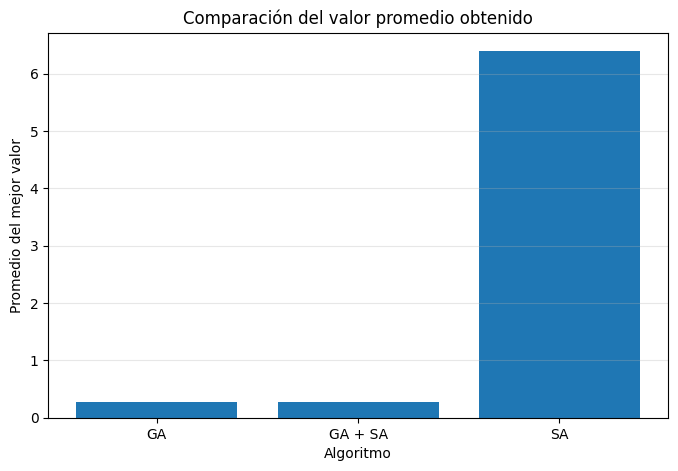

In [11]:
plt.figure(figsize=(8,5))
plt.bar(tabla_promedios["Algoritmo"], tabla_promedios["Promedio_mejor_valor"])
plt.title("Comparación del valor promedio obtenido")
plt.xlabel("Algoritmo")
plt.ylabel("Promedio del mejor valor")
plt.grid(axis="y", alpha=0.3)
plt.show()

## Gráfica de comparación del tiempo promedio

Esta gráfica permite comparar el tiempo promedio de ejecución de cada algoritmo.

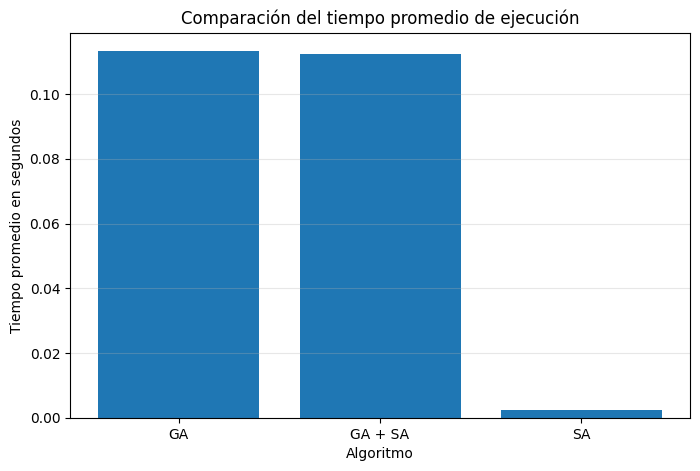

In [12]:
plt.figure(figsize=(8,5))
plt.bar(tabla_promedios["Algoritmo"], tabla_promedios["Promedio_tiempo"])
plt.title("Comparación del tiempo promedio de ejecución")
plt.xlabel("Algoritmo")
plt.ylabel("Tiempo promedio en segundos")
plt.grid(axis="y", alpha=0.3)
plt.show()

## Convergencia promedio de los algoritmos

La convergencia muestra cómo mejora el valor de la función durante las iteraciones.  
Un algoritmo converge mejor cuando reduce más rápido el valor de la función y se acerca a cero.

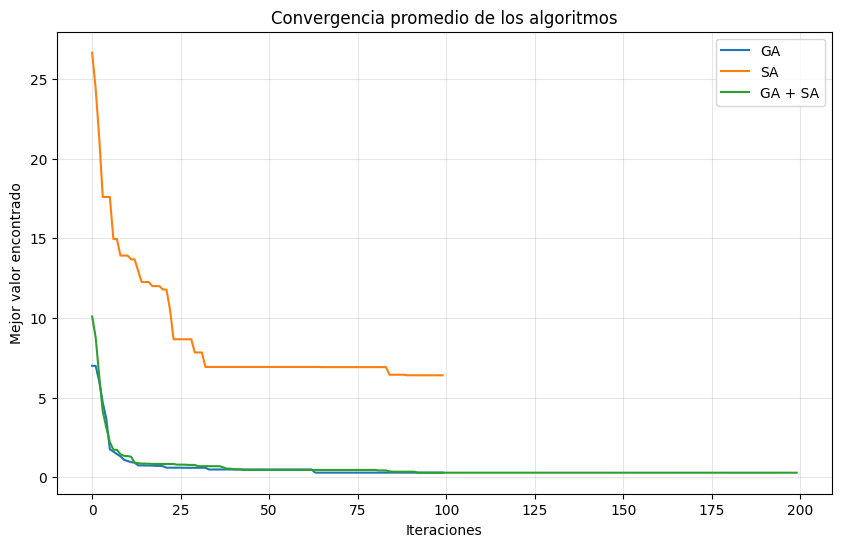

In [13]:
def promedio_historial(lista_historiales):
    '''
    Calcula el promedio de varios historiales.
    Si tienen diferente longitud, se recortan al tamaño mínimo.
    '''
    min_len = min(len(h) for h in lista_historiales)
    matriz = np.array([h[:min_len] for h in lista_historiales])
    return matriz.mean(axis=0)

conv_ga = promedio_historial(historiales["GA"])
conv_sa = promedio_historial(historiales["SA"])
conv_hibrido = promedio_historial(historiales["GA + SA"])

plt.figure(figsize=(10,6))
plt.plot(conv_ga, label="GA")
plt.plot(conv_sa, label="SA")
plt.plot(conv_hibrido, label="GA + SA")
plt.title("Convergencia promedio de los algoritmos")
plt.xlabel("Iteraciones")
plt.ylabel("Mejor valor encontrado")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 5. Análisis comparativo

A continuación se presenta una discusión de los resultados obtenidos, comparando calidad de solución, tiempo de ejecución y convergencia.

### Discusión de resultados

De acuerdo con los resultados obtenidos en las ejecuciones, el algoritmo **GA** permite explorar varias soluciones al mismo tiempo, por lo que generalmente encuentra soluciones aceptables. Sin embargo, al trabajar con una población, puede requerir más tiempo que un algoritmo de trayectoria simple.

El algoritmo **SA** parte de una sola solución y va generando vecinos. Por esta razón puede ser más rápido, pero su resultado depende bastante del punto inicial y de la temperatura. En algunos casos puede encontrar buenas soluciones, pero también puede quedarse en valores menos cercanos al óptimo.

El algoritmo híbrido **GA + SA** combina las ventajas de ambos métodos. Primero, GA busca una buena solución global y luego SA mejora esa solución mediante una búsqueda local. Por esta razón, el híbrido puede obtener mejores resultados en calidad de solución, aunque normalmente requiere mayor tiempo de ejecución porque realiza dos procesos de optimización.

En el contexto de mantenimiento predictivo en **UCEN – Unión Cementera Nacional**, este enfoque híbrido sería útil porque permitiría analizar diferentes combinaciones de variables de equipos industriales y luego ajustar la mejor alternativa para anticipar fallas. Esto ayudaría a mejorar la planificación del mantenimiento, reducir costos, disminuir paradas no programadas y aumentar la disponibilidad operativa de los sistemas productivos.

## Conclusión final

En conclusión, la implementación híbrida **GA + SA** resulta adecuada para problemas de optimización relacionados con mantenimiento predictivo, debido a que combina exploración global y mejora local. Aunque puede requerir más tiempo de ejecución que GA o SA por separado, ofrece una alternativa más robusta para encontrar soluciones de mejor calidad. Para UCEN, este tipo de algoritmo podría apoyar la toma de decisiones en el mantenimiento de equipos críticos, ayudando a prevenir fallas y mejorar la eficiencia de la producción cementera.

## Nota personal

Esta actividad me permitió comprender que los algoritmos bioinspirados y de trayectoria no solo sirven para problemas matemáticos, sino que también pueden aplicarse a situaciones reales de la industria. En el caso de UCEN, el uso de GA + SA puede ayudar a optimizar decisiones de mantenimiento predictivo, especialmente cuando existen muchas variables técnicas que influyen en el estado de los equipos.